In [22]:
from dataclasses import dataclass
from datetime import datetime

import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import numpy as np 
import torch.nn.functional as F
from torch.utils.tensorboard import SummaryWriter
from torchvision import datasets, transforms
from tqdm.auto import tqdm
from torchfuzzy import FuzzyLayer, DefuzzyLinearLayer, FuzzyBellLayer, DefuzzyMaxLayer
import piqa
import sklearn.metrics as metrics
from sklearn.manifold import TSNE
from torchvision.transforms import v2
from torchinfo import summary
from matplotlib.colors import ListedColormap


In [23]:
batch_size = 256
learning_rate_ae = 1e-4
num_epochs_ae = 100
latent_dim = 3
kernels = 8
fuzzy_rules_count = 10

prefix = f"fuzzy_snn"
writer = SummaryWriter(f'runs/mnist/{prefix}_{datetime.now().strftime("%Y%m%d-%H%M%S")}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

binary_cmap = ListedColormap(['yellow', 'red'], N=2)
device

device(type='cuda')

## Датасет  

In [24]:
def norm_and_transform(x):
    nimg = x.view(-1, 28, 28)
    nimg = torch.clamp(nimg, 0, 1)
    return nimg

def clamp(x):
    #nimg = 2.0*(x.view(-1, 28, 28) - 0.5)
    nimg = torch.clamp(x, 0, 1)
    return nimg

transform = transforms.Compose([
    transforms.ToTensor(), 
    transforms.Lambda(norm_and_transform)
])

augmentation = transforms.Compose([
    transforms.RandomRotation(15, fill=0), 
    transforms.RandomAffine(degrees=5, translate=(0.1, 0.1), fill=0), 
    #transforms.RandomCrop(size=26),
    #transforms.Resize(size=(28, 28)),
    transforms.Lambda(clamp)
])

In [25]:
class DatasetWithRandomPairing(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self._dataset = dataset

    def __len__(self):
        return len(self._dataset)

    def __getitem__(self, idx):
        img_a, label_a = self._dataset[idx]
        img_b, label_b = self._dataset[np.random.randint(0,len(self._dataset))]
        return (img_a, img_b, 1 if label_a == label_b else 0, label_a, label_b)

In [26]:
def get_target_and_mask(target_label):
    t = target_label
    return t 

train_data = DatasetWithRandomPairing(datasets.MNIST(
    '~/.pytorch/MNIST_data/', 
    download=True, 
    train=True, 
    transform = transform,
    target_transform = transforms.Lambda(lambda x: get_target_and_mask(x))
))

#idx = (train_data._dataset.targets != mnist_class_anomaly)
#train_data._dataset.targets = train_data._dataset.targets[idx]
#train_data._dataset.data = train_data._dataset.data[idx]
len(train_data)

60000

загружаем тестовую выборку

In [27]:
test_data = DatasetWithRandomPairing(datasets.MNIST(
    '~/.pytorch/MNIST_data/', 
    download=True, 
    train=False, 
    transform=transform, 
    target_transform = transforms.Lambda(lambda x: get_target_and_mask(x))
))
len(test_data)

10000

Создаем итераторы датасетов

In [28]:

train_loader = torch.utils.data.DataLoader(
    train_data, 
    batch_size=batch_size, 
    shuffle=True,
    
)
test_loader = torch.utils.data.DataLoader(
    test_data, 
    batch_size=batch_size, 
    shuffle=False,
)

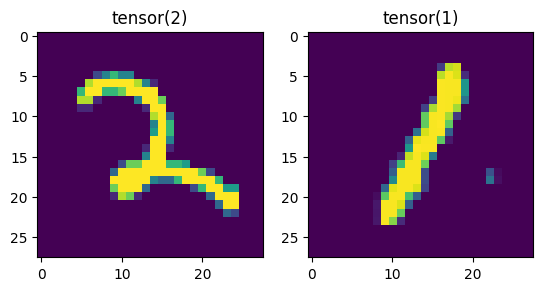

In [32]:
for img_a, img_b, lab, la, lb in iter(train_loader):
    R, C = 1, 2
    #plt.title(lab[0])
    plt.subplot(R, C, 1)
    plt.title(la[0])
    plt.imshow(img_a[0].squeeze())
    plt.subplot(R, C, 2)
    plt.title(lb[0])
    plt.imshow(img_b[0].squeeze())
    
    break

## Модель

In [9]:
class FSNN(nn.Module):

    def __init__(self, latent_dim, fuzzy_rules_count, kernels):
        super(FSNN, self).__init__()
                
        self.encoder = nn.Sequential(
            nn.Conv2d(1, kernels, kernel_size = 5), 
            nn.Conv2d(kernels, kernels, kernel_size = 5), 
            nn.BatchNorm2d(kernels), 
            nn.SiLU(),

            nn.Conv2d(kernels, 2*kernels, kernel_size = 5), 
            nn.Conv2d(2*kernels, 2*kernels, kernel_size = 5), 
            nn.BatchNorm2d(2*kernels), 
            nn.SiLU(),

            nn.Conv2d(2*kernels, 4*kernels, kernel_size = 5), 
            nn.Conv2d(4*kernels, 4*kernels, kernel_size = 5), 
            nn.BatchNorm2d(4*kernels), 
            nn.SiLU(),

            nn.Conv2d(4*kernels, 8*kernels, kernel_size = 4), 
            nn.BatchNorm2d(8*kernels), 
            nn.Flatten(),
            nn.Linear(8*kernels, latent_dim)
        )

        initial_centroids = 1 * np.random.random((fuzzy_rules_count, latent_dim))
        initial_scales = 1 * np.ones((fuzzy_rules_count, latent_dim))
        self.fuzzy = FuzzyLayer.from_centers_and_scales(initial_centroids, initial_scales, trainable=True)
        

    def forward(self, x):
        x = self.encoder(x)
        fz = self.fuzzy(x)
        
        return x, fz

#inp = torch.rand(10, 1, 28, 28)
#m = FSNN(latent_dim, fuzzy_rules_count, 16)
#summary(m, input_size=(batch_size, 1, 28, 28))


In [10]:
fvae = FSNN(latent_dim=latent_dim, fuzzy_rules_count=fuzzy_rules_count, kernels=kernels).to(device)

num_params = sum(p.numel() for p in fvae.parameters() if p.requires_grad)
print(f'Number of parameters: {num_params:,}')

summary(fvae, input_size=(batch_size, 1, 28, 28))

Number of parameters: 83,269


Layer (type:depth-idx)                   Output Shape              Param #
FSNN                                     [256, 3]                  --
├─Sequential: 1-1                        [256, 3]                  --
│    └─Conv2d: 2-1                       [256, 8, 24, 24]          208
│    └─Conv2d: 2-2                       [256, 8, 20, 20]          1,608
│    └─BatchNorm2d: 2-3                  [256, 8, 20, 20]          16
│    └─SiLU: 2-4                         [256, 8, 20, 20]          --
│    └─Conv2d: 2-5                       [256, 16, 16, 16]         3,216
│    └─Conv2d: 2-6                       [256, 16, 12, 12]         6,416
│    └─BatchNorm2d: 2-7                  [256, 16, 12, 12]         32
│    └─SiLU: 2-8                         [256, 16, 12, 12]         --
│    └─Conv2d: 2-9                       [256, 32, 8, 8]           12,832
│    └─Conv2d: 2-10                      [256, 32, 4, 4]           25,632
│    └─BatchNorm2d: 2-11                 [256, 32, 4, 4]           

## Losses

In [11]:
def get_loss(fz_a, fz_b, labels):
    prod = (fz_a*fz_b).sum(-1)

    return torch.where(labels == 0, prod, 1- prod).square().sum()

fz_a = torch.tensor([[1, 0], [0.8, 0.2], [0, 1]])
fz_b = torch.tensor([[1, 0], [0.3, 0.7], [1, 0]])
labels = torch.tensor([1, 1, 0])

get_loss(fz_a, fz_b, labels)
# prod = (fz_a*fz_b).sum(-1)
# torch.where(labs == 0, prod, 1- prod)


tensor(0.3844)

In [12]:
def keep_eigenvals_positive_loss(layer, eps = 1e-10):
    ev = layer.get_transformation_matrix_eigenvals().real.min()
    ev = torch.clamp(ev, max=eps)
    return -ev

In [13]:
def get_match_rates(fz_a, fz_b):
    acts = (fz_a*fz_b).sum(-1)#torch.cat((fz_a.unsqueeze(1), fz_b.unsqueeze(1)), dim=1).min(dim=1).values.squeeze(1).max(dim=1).values
    return acts.cpu().numpy()

## Train AE

In [ ]:
def get_lr(optimizer):
    for param_group in optimizer.param_groups:
        return param_group['lr']
    
def train(model, dataloader, optimizer, sched, prev_updates, epoch, writer=None):
    model.train()  
    
    for batch_idx, (img_a, img_b, labels, _, _) in enumerate(tqdm(dataloader, disable=True)):
        
        aimg_a = augmentation(img_a).to(device)
        aimg_b = augmentation(img_b).to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()  
        
        _, fz_a = model.forward(aimg_a)  
        _, fz_b = model.forward(aimg_b)  

        loss = get_loss(fz_a, fz_b, labels)
        
        ev_loss = keep_eigenvals_positive_loss(model.fuzzy)
        if ev_loss.item() > 0:
            print("ev singularity")
            ev_loss.backward(retain_graph=True)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1e-2)
        optimizer.step()  
        
        if sched is not None:
            sched.step()
        
    if writer is not None:
        writer.add_scalar('FSNN/LR', get_lr(optimizer), global_step=epoch)
        
    return prev_updates + len(dataloader)

In [ ]:
def test(model, dataloader, cur_step, epoch, writer=None):
    model.eval() 

    test_loss = 0.0
    embedings = []
    predicted_label = []
    match_true = []
    match_pred = []

    with torch.no_grad():
        for img_a, img_b, labels, la, lb in tqdm(test_loader, desc='Test MNIST', disable=True):
            aimg_a = img_a.to(device)
            aimg_b = img_b.to(device)
            
            mu_a, fz_a = model.forward(aimg_a)  
            mu_b, fz_b = model.forward(aimg_b)  
            test_loss += (fz_a*fz_b).sum(-1).square().mean().item()
            embedings.append(mu_a.cpu().numpy())
            #fz_a_mx = fz_a.argmax(1)
            predicted_label.append(la.cpu().numpy())#torch.where(fz_a.max(1).values>0.1, fz_a_mx, -1)

            rates = get_match_rates(fz_a, fz_b)
            for f, l in  zip(rates, labels):
                match_pred.append(f)        
                if l == 1:
                    match_true.append(1)
                else:
                    match_true.append(0)
            
    fpr, tpr, _ = metrics.roc_curve(match_true, match_pred)
    roc_auc = metrics.auc(fpr, tpr)

    embedings = np.concatenate(embedings, axis=0)
    predicted_label= np.concatenate(predicted_label, axis=0)
    test_loss /= len(dataloader)
    
    print(f'[{cur_step}] Loss: {test_loss:.4f} AUC: {roc_auc:.4f}')
    
    if writer is not None:
        writer.add_scalar('FSNN/AUC', roc_auc, global_step=cur_step)
        writer.add_scalar('FSNN/Loss', test_loss, global_step=cur_step)
        
        fig, ax = plt.subplots(1, 2, figsize=(9, 4))
        
        ax[0].scatter(embedings[:, 0],      embedings[:,  1], c=predicted_label, cmap='tab10', s=2)
        ax[1].scatter(embedings[:, 0],      embedings[:,  2], c=predicted_label, cmap='tab10', s=2)
        
        
        writer.add_figure('FSNN/Emedding', fig, global_step=cur_step)

In [16]:
prev_updates = 0
optimizer_ae = torch.optim.Adam(fvae.parameters(), lr=learning_rate_ae)
#sched = torch.optim.lr_scheduler.OneCycleLR(optimizer_ae, learning_rate_ae, epochs=num_epochs_ae, steps_per_epoch=len(train_loader))
sched = torch.optim.lr_scheduler.ConstantLR(optimizer_ae, learning_rate_ae)

In [17]:
for epoch in range(num_epochs_ae):    
    prev_updates = train(fvae, train_loader, optimizer_ae, sched, prev_updates, epoch, writer=writer)
    test(fvae, test_loader, prev_updates, epoch, writer=writer)
    #scheduler.step()

[235] Loss: 0.0075 AUC: 0.5143
[470] Loss: 0.0085 AUC: 0.5193
[705] Loss: 0.0107 AUC: 0.5234
[940] Loss: 0.0060 AUC: 0.5022
[1175] Loss: 0.0098 AUC: 0.5079
[1410] Loss: 0.0074 AUC: 0.5218
[1645] Loss: 0.0119 AUC: 0.5014
[1880] Loss: 0.0075 AUC: 0.4979
[2115] Loss: 0.0106 AUC: 0.5277
[2350] Loss: 0.0097 AUC: 0.4967
[2585] Loss: 0.0115 AUC: 0.4874
[2820] Loss: 0.0085 AUC: 0.5180
[3055] Loss: 0.0129 AUC: 0.5075
[3290] Loss: 0.0113 AUC: 0.4959
[3525] Loss: 0.0156 AUC: 0.4707
[3760] Loss: 0.0146 AUC: 0.4904
[3995] Loss: 0.0159 AUC: 0.5001
[4230] Loss: 0.0156 AUC: 0.4893
[4465] Loss: 0.0149 AUC: 0.5140
[4700] Loss: 0.0142 AUC: 0.5501
[4935] Loss: 0.0131 AUC: 0.6040
[5170] Loss: 0.0181 AUC: 0.5614
[5405] Loss: 0.0151 AUC: 0.6251
[5640] Loss: 0.0180 AUC: 0.6244
[5875] Loss: 0.0174 AUC: 0.6276
[6110] Loss: 0.0190 AUC: 0.6129
[6345] Loss: 0.0164 AUC: 0.6239
[6580] Loss: 0.0161 AUC: 0.6436
[6815] Loss: 0.0169 AUC: 0.6498
[7050] Loss: 0.0174 AUC: 0.6605
[7285] Loss: 0.0208 AUC: 0.6342
[7520] Loss:

## Визуализируем результаты

In [18]:
fvae.eval()

FSNN(
  (encoder): Sequential(
    (0): Conv2d(1, 8, kernel_size=(5, 5), stride=(1, 1))
    (1): Conv2d(8, 8, kernel_size=(5, 5), stride=(1, 1))
    (2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): SiLU()
    (4): Conv2d(8, 16, kernel_size=(5, 5), stride=(1, 1))
    (5): Conv2d(16, 16, kernel_size=(5, 5), stride=(1, 1))
    (6): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): SiLU()
    (8): Conv2d(16, 32, kernel_size=(5, 5), stride=(1, 1))
    (9): Conv2d(32, 32, kernel_size=(5, 5), stride=(1, 1))
    (10): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): SiLU()
    (12): Conv2d(32, 64, kernel_size=(4, 4), stride=(1, 1))
    (13): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): Flatten(start_dim=1, end_dim=-1)
    (15): Linear(in_features=64, out_features=3, bias=True)
  )
  (fuzzy): FuzzyLayer(
    (rots): ParameterLis

In [19]:
def get_arate_val(inp):
    mu, fz, c = fvae.half_pass(inp)  
    #fz = fvae.fuzzy_pass(mu)
    #recon_x = model.decoder_pass(z)
    return fz.sum(-1).cpu().numpy() ##(1 - ssim(x_recon.clamp(0, 1), inp)).cpu().numpy()#xent_continuous_ber((x_recon + 1)/2, (inp + 1)/2).cpu().numpy()# #ssim((inp + 1)/2, (recon_x+1)/2).cpu().numpy() #fz.sum(-1).cpu().numpy()#

In [20]:
firings_mnist = {}
firings_mnist['MNIST'] = []
firings_mnist['DISSIDENT'] = []

with torch.no_grad():
    for data, target in tqdm(test_loader, desc='MNIST HIST'):
        data = data.view((-1,1,28,28)).to(device)
        rates = get_arate_val(data)
        for f, l in  zip(rates, target):
            if l != mnist_class_anomaly:
                firings_mnist['MNIST'].append(f)
            else:
                firings_mnist['DISSIDENT'].append(f)
        

labels, data = firings_mnist.keys(), firings_mnist.values()

fig = plt.figure(figsize =(12, 2))
plt.boxplot(data, notch=True, showfliers=False)
plt.xticks(range(1, len(labels) + 1), labels)
plt.show()

writer.add_figure('Anomaly Detection', fig)

MNIST HIST:   0%|          | 0/40 [00:00<?, ?it/s]

ValueError: too many values to unpack (expected 2)

In [ ]:
with torch.no_grad():
    firing_levels = []
    lab_true = []
    lab_pred = []

    for data, lab in tqdm(test_loader, desc='Test MNIST', disable=True):
        data = data.view((-1,1,28,28)).to(device)
        rates = get_arate_val(data)
        
        for f, l in  zip(rates, lab):
            firing_levels.append(f)
            lab_pred.append(f)        
            if l == mnist_class_anomaly:
                lab_true.append(1)
            else:
                lab_true.append(0)
                    
    fpr, tpr, threshold = metrics.roc_curve(lab_true, lab_pred)
    roc_auc = metrics.auc(fpr, tpr)
    optimal_idx = np.argmax(tpr - fpr)
    optimal_threshold = threshold[optimal_idx]
    fig = plt.figure(figsize =(4, 4))
    plt.title('Receiver Operating Characteristic')
    plt.plot(fpr, tpr, 'b', label = 'AUC = %0.2f' % roc_auc)
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()
    writer.add_figure('ROC', fig)

In [ ]:


def show_plot():
    #centroids = model.fuzzy[0].get_centroids().detach().cpu().numpy()
    embedings = []
    labels_expected = []
    with torch.no_grad():
        for data, target in tqdm(test_loader, desc='Encoding'):
            data = data.view((-1,1,28,28)).to(device)
            mu,_,_ = fvae.half_pass(data)
            embedings.append(mu.cpu().numpy())
            #labels_expected.append((target == mnist_class_anomaly).cpu().numpy())
            labels_expected.append(target.cpu().numpy())
    embedings = np.concatenate(embedings, axis=0)
    labels_expected = np.concatenate(labels_expected, axis=0)

    plt.figure(figsize=(18, 6))

    R, C = 1, 3

    plt.subplot(R, C, 1)
    plt.title("MNIST XY")
    
    plt.scatter(embedings[:, 0],      embedings[:,  1], c=labels_expected, cmap='tab10', s=2)
    #plt.scatter(centroids[:, 0],      centroids[:, 1], marker='1', c='black', s= 50)

    plt.subplot(R, C, 2)
    plt.title("MNIST XZ")
    plt.scatter(embedings[:, 0],      embedings[:,  2], c=labels_expected, cmap='tab10', s=2)
    #plt.scatter(centroids[:, 0],      centroids[:, 2], marker='1', c='black', s= 50)

    
show_plot()

In [ ]:
def show_item_reconstructio(ind):
    for data, trg in iter(test_loader):
        data = data.to(device)
        mu, fz = fvae.half_pass(data)
        rec_x = fvae.decoder_pass(fz)
        plt.figure(figsize=(24, 6))

        R, C = 1, 6

        plt.subplot(R, C, 1)
        plt.imshow(data[ind].cpu().squeeze())
        plt.subplot(R, C, 2)
        plt.imshow(rec_x[ind].detach().cpu().squeeze())
        
        plt.subplot(R, C, 3)
        plt.imshow((rec_x[ind] - data[ind]).abs().detach().cpu().squeeze())
        break

In [ ]:
show_item_reconstructio(4)
show_item_reconstructio(3)

In [ ]:
threshold = optimal_threshold
n = 0
fig, ax = plt.subplots(10, 10, figsize=(10, 10))
with torch.no_grad():
    for data, labels in tqdm(test_loader, desc='EMNIST VIS'):
        if n >= 100:
            break
        data = data.view((-1, 1, 28, 28)).to(device) 
        
        arate = get_arate_val(data)
        
        for i in range(data.shape[0]):
            if(arate[i] > threshold):
                img = data[i]
                ax[int(n / 10), int(n % 10)].imshow(img.view(28, 28).cpu().detach().numpy(), cmap='gray')
                ax[int(n / 10), int(n % 10)].axis('off')
                n = n + 1
                    
                if n >= 100:
                    break